# Modeling notebook — Predicting reject-button effectiveness

**The question:** when a website shows a "reject" button on its cookie banner, does clicking it *actually* bring the tracker count down to zero? Or is the button just decoration?

**Why a model:** the real differential test (click reject -> recount trackers) only worked on ~38% of my scraped sites — it's slow and breaks a lot (shadow DOM, headless detection, timeouts). But the *pre-consent* signals (trackers, cookies, ad networks, CMP vendor) are cheap to scrape on any site. So: train on the 1,583 sites where I have ground truth, then the Streamlit app estimates reject-effectiveness from a light pre-consent scan alone.

**Golden rule:** the model only sees features that exist BEFORE any interaction with the banner. Nothing measured after the reject click goes into X — otherwise I'd be predicting the answer from the answer.

**Plan:**
- prepare the data and the target
- for each model: default version -> evaluate -> overfitting check -> GridSearchCV -> tuned version
- models: Logistic Regression, Decision Tree, Random Forest, XGBoost
- compare all default models, compare all tuned models, pick the winner

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             f1_score, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)

In [2]:
df = pd.read_csv("../clean_data/dataset_completed_clean.csv")
print("Dataset loaded with shape:", df.shape)
df.head()

Dataset loaded with shape: (4100, 31)


,url,cookies_before_interaction,non_essential_cookies_before_interaction,long_lived_cookies_count,tracker_count,ad_network_count,cmp_detected,tcf_api_present,has_accept_button,has_reject_button,...,country,country_code,region,isp,org,asn,is_hosting,lat,lon,reject_test_looks_noisy
0,https://telekom.de,5.0,5.0,0.0,3.0,3.0,none,False,True,True,...,Germany,DE,Hesse,Amazon Technologies Inc.,AWS EC2 (eu-central-1),"AS16509 Amazon.com, Inc.",True,50.1109,8.68213,False
1,https://t-online.de,3.0,1.0,0.0,8.0,1.0,sourcepoint,True,True,False,...,Ireland,IE,Leinster,Amazon Technologies Inc.,AWS EC2 (eu-west-1),"AS16509 Amazon.com, Inc.",True,53.3498,-6.26031,False
2,https://bbc.co.uk,16.0,16.0,6.0,25.0,15.0,none,True,True,True,...,Canada,CA,Quebec,"Fastly, Inc.","Fastly, Inc.","AS54113 Fastly, Inc.",True,45.5019,-73.56740,False
3,https://www.gov.uk,1.0,1.0,0.0,4.0,1.0,none,False,True,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,https://amazon.co.uk,10.0,10.0,0.0,8.0,4.0,cookie notice,True,True,True,...,Ireland,IE,Leinster,Amazon Technologies Inc.,Amazon Technologies Inc. (eu-west-1),"AS16509 Amazon.com, Inc.",True,53.3498,-6.26031,False


In [3]:
df.columns

Index(['url', 'cookies_before_interaction',
       'non_essential_cookies_before_interaction', 'long_lived_cookies_count',
       'tracker_count', 'ad_network_count', 'cmp_detected', 'tcf_api_present',
       'has_accept_button', 'has_reject_button', 'has_cookie_banner',
       'reject_as_visible_as_accept', 'prechecked_boxes_detected',
       'reject_click_attempted', 'reject_click_succeeded',
       'tracker_count_after_reject', 'non_essential_cookies_after_reject',
       'has_privacy_policy', 'robots_txt_present', 'domain', 'flagged_unsafe',
       'country', 'country_code', 'region', 'isp', 'org', 'asn', 'is_hosting',
       'lat', 'lon', 'reject_test_looks_noisy'],
      dtype='object')

## Prepare the modeling data

The dataset has 4,101 sites, but `tracker_count_after_reject` only exists where my scraper
found a reject button AND managed to click it. Everywhere else that column is NaN — not
missing data, just "the test couldn't run there". Those rows have no ground truth, so out
they go.

In [4]:
df_model = df[df["reject_click_attempted"] == True].copy()
print(f"Rows with a usable differential test: {len(df_model)} / {len(df)}")

Rows with a usable differential test: 1583 / 4100


## Create the target

Reject "works" if the tracker count drops to exactly 0 after the click. Strict on purpose:
from a GDPR point of view, a reject click should mean no non-essential tracking, full stop.
(Flagged as a limitation at the end.)

Then check the balance — if 95% of sites were in one class, the model could predict the
majority every time and look accurate while learning nothing.

In [5]:
df_model["reject_works"] = (df_model["tracker_count_after_reject"] == 0).astype(int)

# Check the balance
print("Target distribution:")
print(df_model["reject_works"].value_counts())
print()
print((df_model["reject_works"].value_counts(normalize=True) * 100).round(1))

Target distribution:
reject_works
0    899
1    684
Name: count, dtype: int64

reject_works
0    56.8
1    43.2
Name: proportion, dtype: float64


    =>  ~57% / ~43% -> nicely balanced, no resampling needed

## Feature engineering

Two transformations before selecting features:

**a) `uses_major_cloud_cdn`** — the raw `org` column (hosting provider) has hundreds of
unique values, too many to encode. I collapse it to one boolean: is the site on major
cloud/CDN infrastructure or not.

**b) group rare CMP vendors** — `cmp_detected` has ~12 vendors but some appear on only a
handful of sites. One-hot encoding those would create near-empty columns that are pure
noise. Everything under 20 sites gets bucketed into `'other'`.

In [6]:
# a) hosting: hundreds of org names -> one yes/no feature
MAJOR_CLOUD_CDN = ['amazon', 'google', 'fastly', 'akamai', 'cloudflare', 'microsoft','OVH', 'Oracle','WP']

pattern = '|'.join(MAJOR_CLOUD_CDN)   # keywords have no regex metacharacters -> safe

df_model['uses_major_cloud_cdn'] = (
    df_model['org']
    .fillna('')
    .str.lower()
    .str.contains(pattern, regex=True)
)

print(df_model['uses_major_cloud_cdn'].value_counts())

uses_major_cloud_cdn
False    993
True     590
Name: count, dtype: int64


In [7]:
# b) CMP vendors: bucket the rare ones so one-hot encoding stays sane
cmp_counts = df_model["cmp_detected"].value_counts()
rare_cmps = cmp_counts[cmp_counts < 20].index

df_model["cmp_grouped"] = df_model["cmp_detected"].replace(rare_cmps, "other")

print(df_model["cmp_grouped"].value_counts())

cmp_grouped
none              576
onetrust          387
didomi            132
usercentrics       95
other              71
trustarc           66
cookiebot          64
sourcepoint        54
iubenda            51
cookie notice      36
cookieyes          28
trustcommander     23
Name: count, dtype: int64


## Select features and split

Golden rule reminder: **pre-interaction features only.** Explicitly NOT in the features:
`tracker_count_after_reject` (that's the answer) and `reject_click_succeeded` (only
knowable after interacting).

`cmp_grouped` is text, so it gets one-hot encoded with `get_dummies` (each vendor becomes
its own 0/1 column). The booleans become 0/1, with the couple of NaN rows filled as False.

In [8]:
df_model.columns

Index(['url', 'cookies_before_interaction',
       'non_essential_cookies_before_interaction', 'long_lived_cookies_count',
       'tracker_count', 'ad_network_count', 'cmp_detected', 'tcf_api_present',
       'has_accept_button', 'has_reject_button', 'has_cookie_banner',
       'reject_as_visible_as_accept', 'prechecked_boxes_detected',
       'reject_click_attempted', 'reject_click_succeeded',
       'tracker_count_after_reject', 'non_essential_cookies_after_reject',
       'has_privacy_policy', 'robots_txt_present', 'domain', 'flagged_unsafe',
       'country', 'country_code', 'region', 'isp', 'org', 'asn', 'is_hosting',
       'lat', 'lon', 'reject_test_looks_noisy', 'reject_works',
       'uses_major_cloud_cdn', 'cmp_grouped'],
      dtype='object')

In [9]:
numeric_features = [
    'tracker_count',
    'ad_network_count',
    'cookies_before_interaction',
    'non_essential_cookies_before_interaction',
    'long_lived_cookies_count',
]
bool_features = ['has_privacy_policy', 'is_hosting', 'uses_major_cloud_cdn']

# tiny number of NaNs in the boolean columns -> fill with False, keep the rows
for col in bool_features:
    df_model[col] = df_model[col].fillna(False).astype(bool)

X = pd.concat([
    df_model[numeric_features],
    df_model[bool_features].astype(int),
    pd.get_dummies(df_model['cmp_grouped'], prefix='cmp'),
], axis=1)

y = df_model['reject_works']

print('X shape:', X.shape)
X.head()

X shape: (1583, 20)


/var/folders/9l/kk5xty3s5gn6t443byvnr8040000gn/T/ipykernel_13323/970540387.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col] = df_model[col].fillna(False).astype(bool)
/var/folders/9l/kk5xty3s5gn6t443byvnr8040000gn/T/ipykernel_13323/970540387.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col] = df_model[col].fillna(False).astype(bool)


,tracker_count,ad_network_count,cookies_before_interaction,non_essential_cookies_before_interaction,long_lived_cookies_count,has_privacy_policy,is_hosting,uses_major_cloud_cdn,cmp_cookie notice,cmp_cookiebot,cmp_cookieyes,cmp_didomi,cmp_iubenda,cmp_none,cmp_onetrust,cmp_other,cmp_sourcepoint,cmp_trustarc,cmp_trustcommander,cmp_usercentrics
0,3.0,3.0,5.0,5.0,0.0,1,1,0,False,False,False,False,False,True,False,False,False,False,False,False
2,25.0,15.0,16.0,16.0,6.0,1,1,1,False,False,False,False,False,True,False,False,False,False,False,False
3,4.0,1.0,1.0,1.0,0.0,1,0,0,False,False,False,False,False,True,False,False,False,False,False,False
4,8.0,4.0,10.0,10.0,0.0,1,1,1,True,False,False,False,False,False,False,False,False,False,False,False
5,30.0,15.0,15.0,15.0,4.0,1,0,1,False,False,False,False,False,False,False,False,False,True,False,False


## Correlation check before locking in the features

Two features carrying near-identical information isn't free: it dilutes feature importance
between them and adds noise. Same heatmap recipe as usual (`np.abs(corr)` + upper-triangle
mask), run on X since that's what the model actually sees.

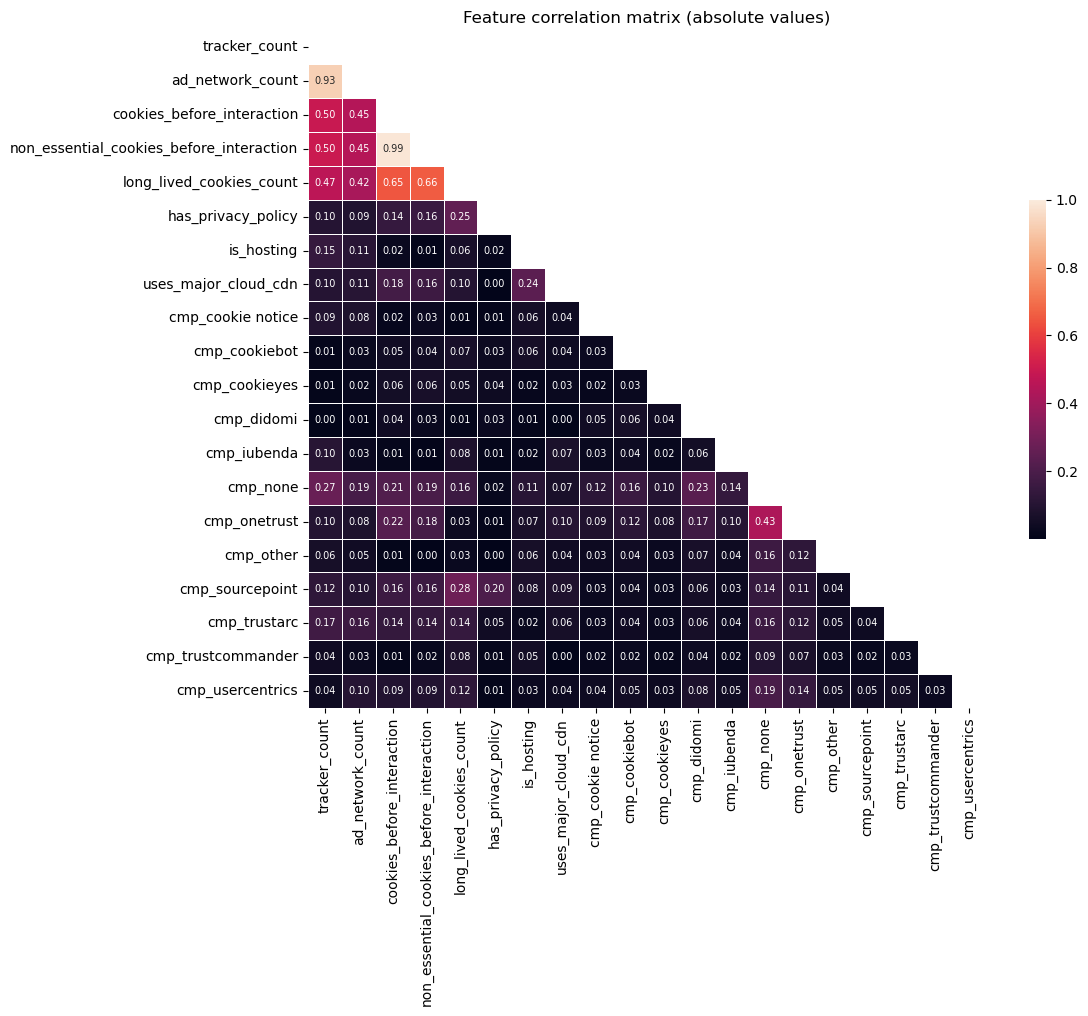

In [10]:
corr = np.abs(X.corr())

# mask the upper triangle -- it's a mirror of the lower one
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .5}, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Feature correlation matrix (absolute values)")
plt.tight_layout()
plt.show()

**What it shows:** `cookies_before_interaction` and
`non_essential_cookies_before_interaction` are correlated at ~0.99 — basically the same
column twice (on these sites almost every pre-consent cookie is non-essential). Keeping
both adds redundancy, not signal -> dropping the generic one, keeping the more specific
non-essential count.

`tracker_count` vs `ad_network_count` sit at ~0.93 — related but conceptually distinct
(ad networks are one *type* of tracker). Keeping both, noted as a limitation.

In [11]:
# apply the one change the correlation check justified
X = X.drop(columns=["cookies_before_interaction"])
print("X shape after dropping the redundant column:", X.shape)

X shape after dropping the redundant column: (1583, 19)


In [12]:
# 80% for training, 20% for testing
# random_state=42 ensures same split every time you run
# stratify=y ensures both sets have the same proportion of works/doesn't work
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} sites")
print(f"Test set: {len(X_test)} sites")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Training set: 1266 sites
Test set: 317 sites

Training target distribution:
reject_works
0    719
1    547
Name: count, dtype: int64

Test target distribution:
reject_works
0    180
1    137
Name: count, dtype: int64


**Scale the features**

Logistic Regression cares about feature scale — otherwise big numbers (tracker counts in
the dozens) dominate small ones (0/1 dummies). Tree models (Decision Tree, Random Forest,
XGBoost) don't need scaling, so they'll use the original unscaled splits.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")
print(f"Example — before: tracker_count mean = {X_train['tracker_count'].mean():.1f}")
print(f"Example — after:  tracker_count mean = {X_train_scaled[:, list(X.columns).index('tracker_count')].mean():.2f}")

Scaling done!
Example — before: tracker_count mean = 15.7
Example — after:  tracker_count mean = -0.00


**The number to beat**

Before any model: if I just predicted the majority class ("reject doesn't work") for every
site, what accuracy would I get? Any model has to clearly beat this to be worth anything.

In [14]:
majority_share = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {majority_share:.3f}")

Majority-class baseline accuracy: 0.568


# LOGISTIC REGRESSION

The simplest real model: a linear model that outputs a probability. Good first benchmark —
if it performs close to the fancy models, the relationship is fairly linear. Uses the
SCALED features.

In [15]:
logreg_default = LogisticRegression(max_iter=1000, random_state=42)
logreg_default.fit(X_train_scaled, y_train)
y_pred_lr_default = logreg_default.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr_default, target_names=["Doesn't work", "Works"]))

=== LOGISTIC REGRESSION (default) ===
Accuracy: 0.767

Classification Report:
              precision    recall  f1-score   support

Doesn't work       0.79      0.80      0.80       180
       Works       0.73      0.72      0.73       137

    accuracy                           0.77       317
   macro avg       0.76      0.76      0.76       317
weighted avg       0.77      0.77      0.77       317



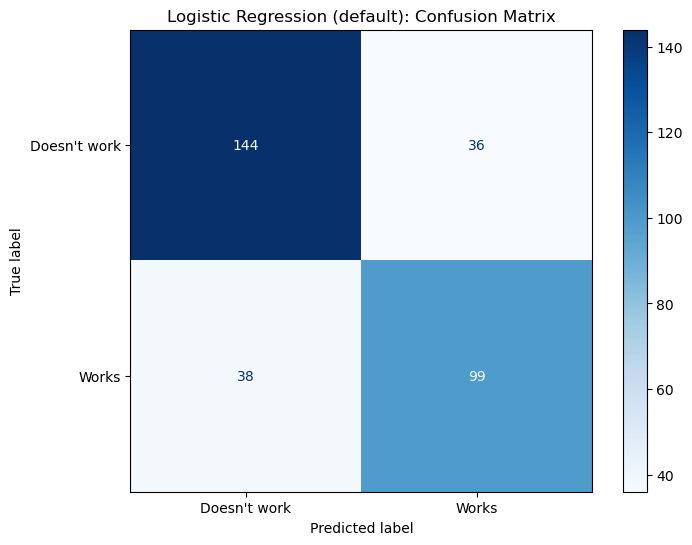

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    logreg_default, X_test_scaled, y_test,
    display_labels=["Doesn't work", "Works"],
    cmap="Blues", ax=ax
)
plt.title("Logistic Regression (default): Confusion Matrix")
plt.show()

**Overfitting check**

In [17]:
# Rule of thumb:
#   Gap < 0.05 -> excellent
#   Gap 0.05-0.10 -> acceptable
#   Gap > 0.10 -> overfitting, needs tuning

train_acc_lr = accuracy_score(y_train, logreg_default.predict(X_train_scaled))
test_acc_lr = accuracy_score(y_test, y_pred_lr_default)

print(f"Train accuracy: {train_acc_lr:.3f}")
print(f"Test accuracy:  {test_acc_lr:.3f}")
print(f"Gap:            {train_acc_lr - test_acc_lr:.3f}")

if train_acc_lr - test_acc_lr > 0.10:
    print("Possible overfitting — tuning should help")
else:
    print("No major overfitting")

Train accuracy: 0.764
Test accuracy:  0.767
Gap:            -0.003
No major overfitting


**GridSearch for Logistic Regression**

In [18]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],          # regularization strength (smaller = more regularization)
    "solver": ["lbfgs", "liblinear"]   # optimization algorithm
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best F1 score (cross-validated): {grid_lr.best_score_:.3f}")

best_lr = grid_lr.best_estimator_
y_pred_best_lr = best_lr.predict(X_test_scaled)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best_lr):.3f}")

Best parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best F1 score (cross-validated): 0.729
Test accuracy: 0.763


# DECISION TREE

A single tree asking cascading questions. Tree-based -> uses the UNSCALED features.
Starting with max_depth=4 so the tree stays small enough to actually read.

In [19]:
dt_default = DecisionTreeClassifier(
    max_depth=4,        # limit to 4 levels of questions
    random_state=42     # reproducible results
)

dt_default.fit(X_train, y_train)
y_pred_dt_default = dt_default.predict(X_test)

print("=== DECISION TREE (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt_default, target_names=["Doesn't work", "Works"]))

=== DECISION TREE (default) ===
Accuracy: 0.820

Classification Report:
              precision    recall  f1-score   support

Doesn't work       0.84      0.84      0.84       180
       Works       0.79      0.79      0.79       137

    accuracy                           0.82       317
   macro avg       0.82      0.82      0.82       317
weighted avg       0.82      0.82      0.82       317



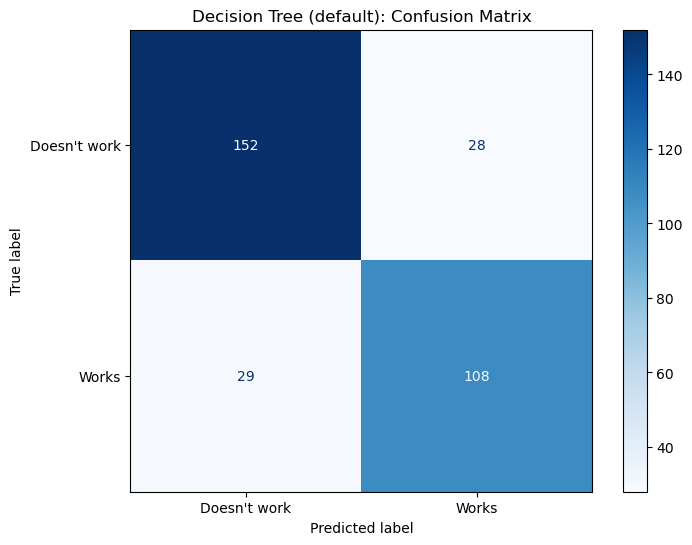

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    dt_default, X_test, y_test,
    display_labels=["Doesn't work", "Works"],
    cmap="Blues", ax=ax
)
plt.title("Decision Tree (default): Confusion Matrix")
plt.show()

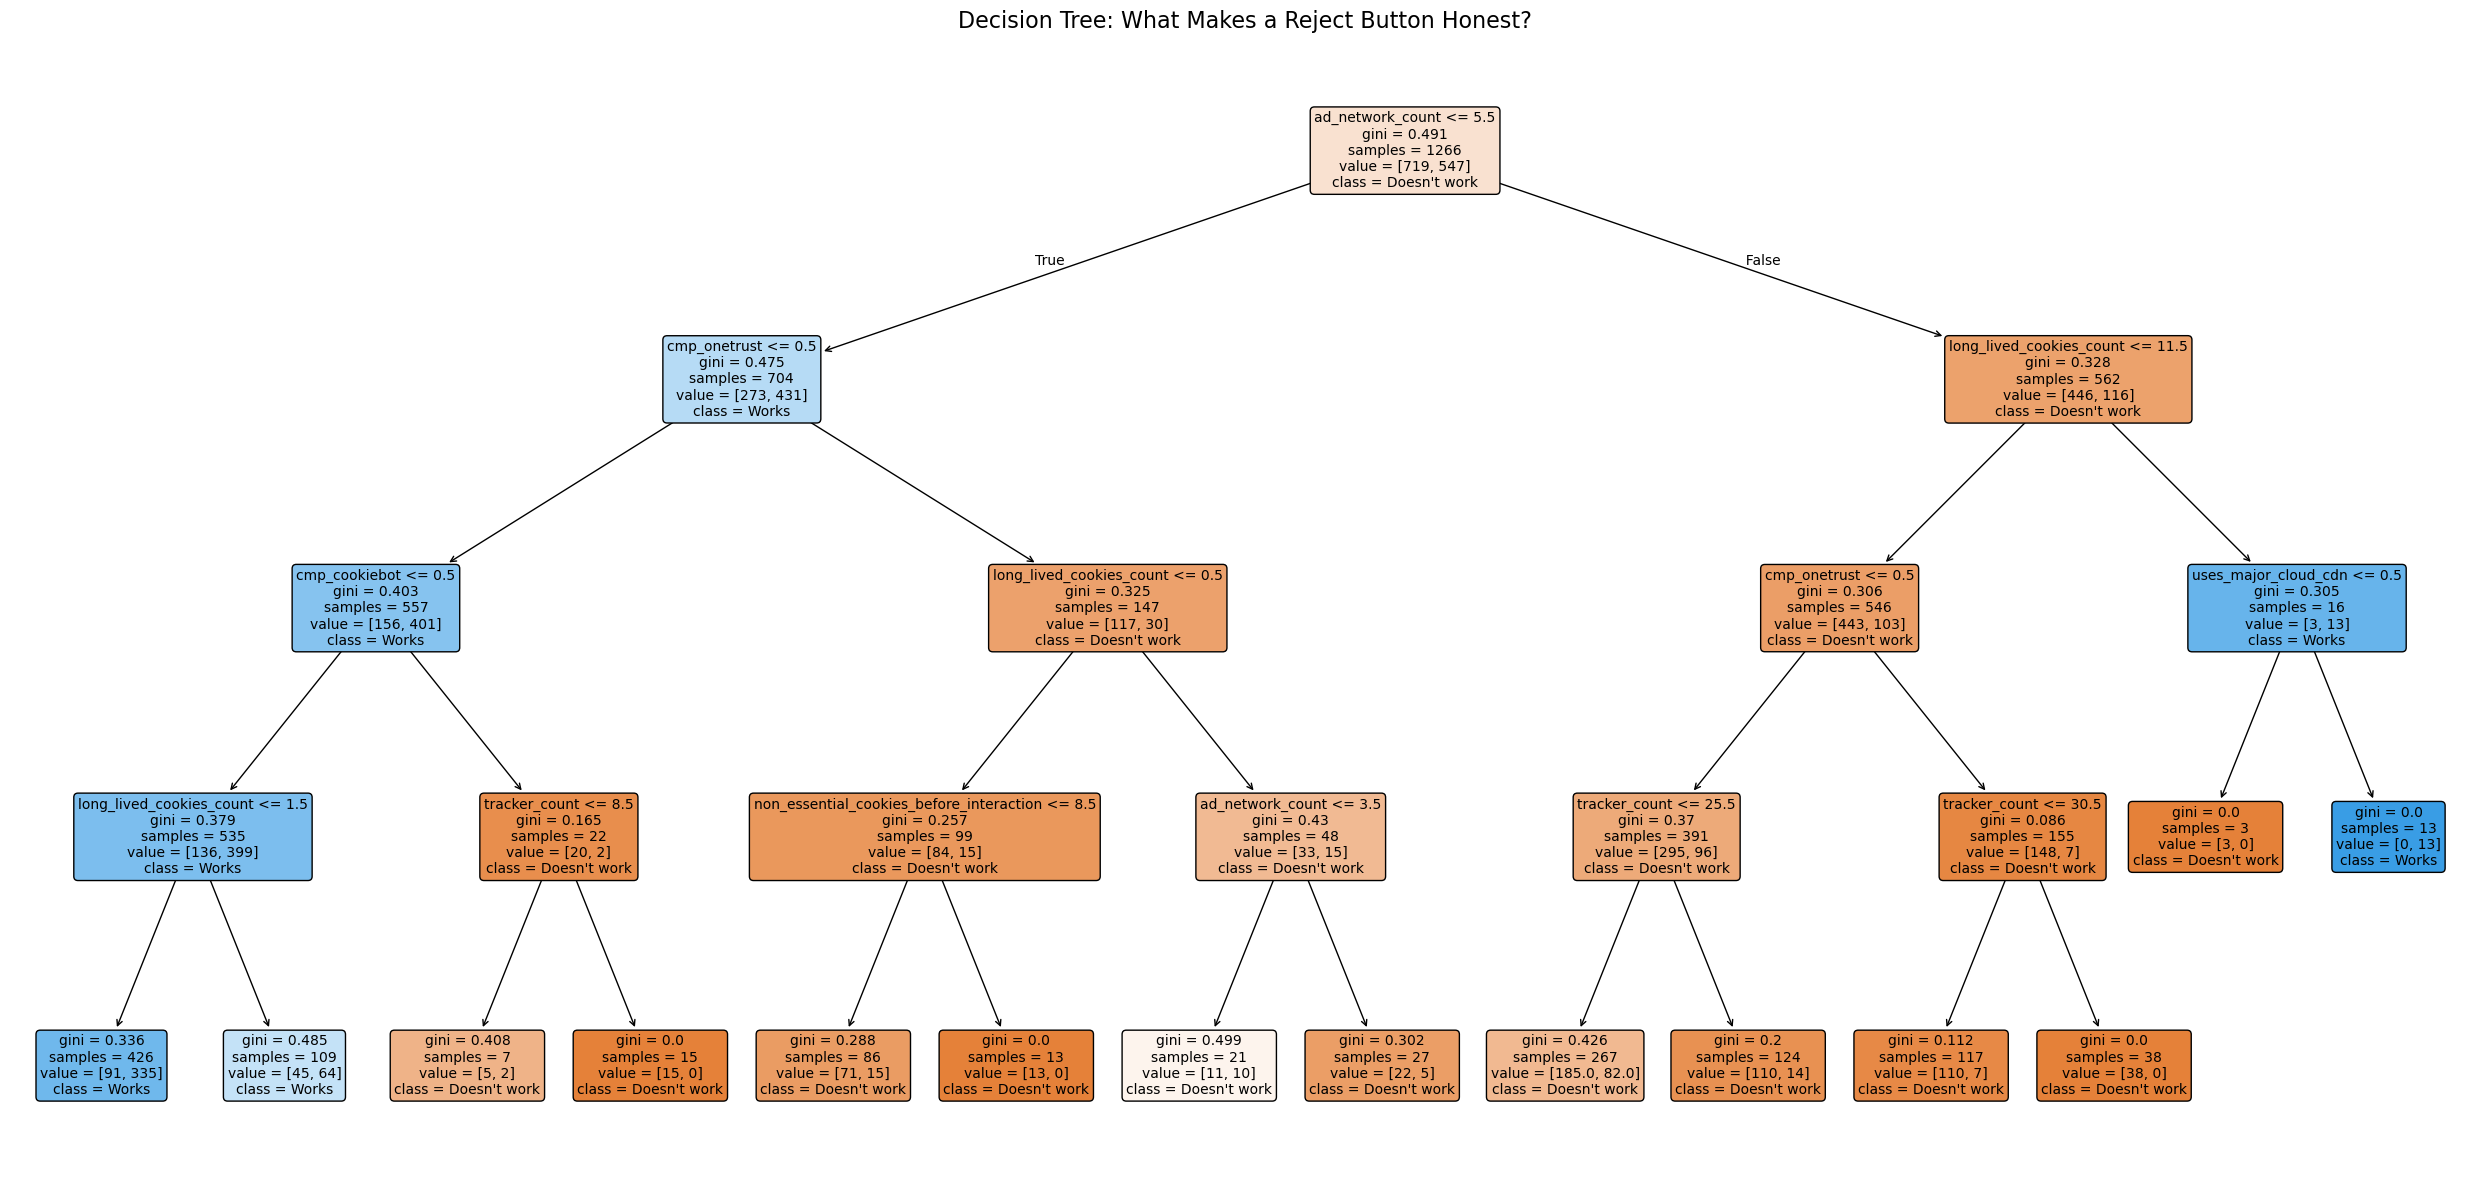

In [21]:
plt.figure(figsize=(25, 12))
plot_tree(
    dt_default,
    feature_names=list(X.columns),
    class_names=["Doesn't work", "Works"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree: What Makes a Reject Button Honest?", fontsize=16)
plt.tight_layout()
plt.show()

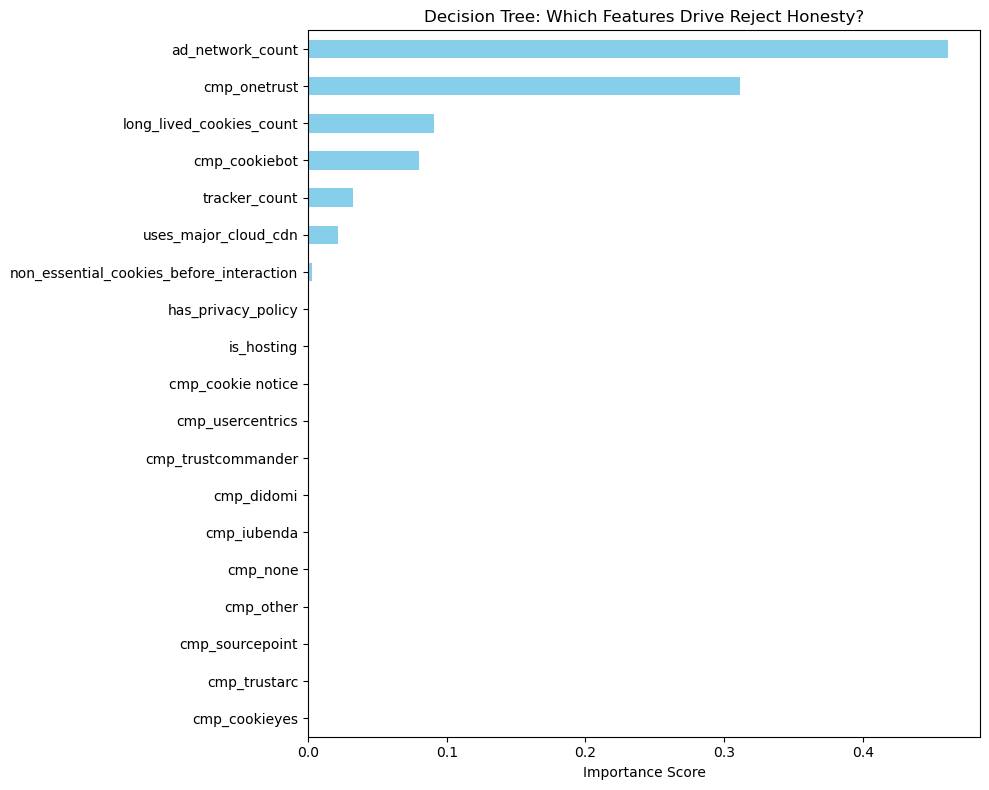


Top 5 most important features:
ad_network_count            0.461310
cmp_onetrust                0.311295
long_lived_cookies_count    0.090849
cmp_cookiebot               0.079683
tracker_count               0.032410
dtype: float64


In [22]:
importance_dt = pd.Series(
    dt_default.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
importance_dt.plot(kind="barh", color="skyblue")
plt.xlabel("Importance Score")
plt.title("Decision Tree: Which Features Drive Reject Honesty?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_dt.sort_values(ascending=False).head())

In [23]:
train_acc_dt = accuracy_score(y_train, dt_default.predict(X_train))
test_acc_dt = accuracy_score(y_test, y_pred_dt_default)

print(f"Train accuracy: {train_acc_dt:.3f}")
print(f"Test accuracy:  {test_acc_dt:.3f}")
print(f"Gap:            {train_acc_dt - test_acc_dt:.3f}")

if train_acc_dt - test_acc_dt > 0.10:
    print("Possible overfitting — tuning should help")
else:
    print("No major overfitting")

Train accuracy: 0.786
Test accuracy:  0.820
Gap:            -0.034
No major overfitting


**GridSearch for Decision Tree**

In [24]:
param_grid_dt = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best F1 (cross-validated): {grid_dt.best_score_:.3f}")

Best parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 (cross-validated): 0.753


In [25]:
best_dt = grid_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("=== DECISION TREE (tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_dt):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt, target_names=["Doesn't work", "Works"]))

# Compare with default
print(f"\n--- Improvement ---")
print(f"Default accuracy: {accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"Tuned accuracy:   {accuracy_score(y_test, y_pred_best_dt):.3f}")

=== DECISION TREE (tuned) ===
Accuracy: 0.820

Classification Report:
              precision    recall  f1-score   support

Doesn't work       0.84      0.84      0.84       180
       Works       0.79      0.79      0.79       137

    accuracy                           0.82       317
   macro avg       0.82      0.82      0.82       317
weighted avg       0.82      0.82      0.82       317


--- Improvement ---
Default accuracy: 0.820
Tuned accuracy:   0.820


# RANDOM FOREST

Random Forest is an ensemble of decision trees. Unlike a single tree:
- It averages many trees, which reduces overfitting
- It handles raw (unscaled) features well
- Gives feature importance scores
- Tends to be more robust to outliers and noise

In [26]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

print(f"Baseline Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Doesn't work", "Works"]))

Baseline Random Forest Accuracy: 0.808

Classification Report:
              precision    recall  f1-score   support

Doesn't work       0.82      0.84      0.83       180
       Works       0.79      0.76      0.77       137

    accuracy                           0.81       317
   macro avg       0.80      0.80      0.80       317
weighted avg       0.81      0.81      0.81       317



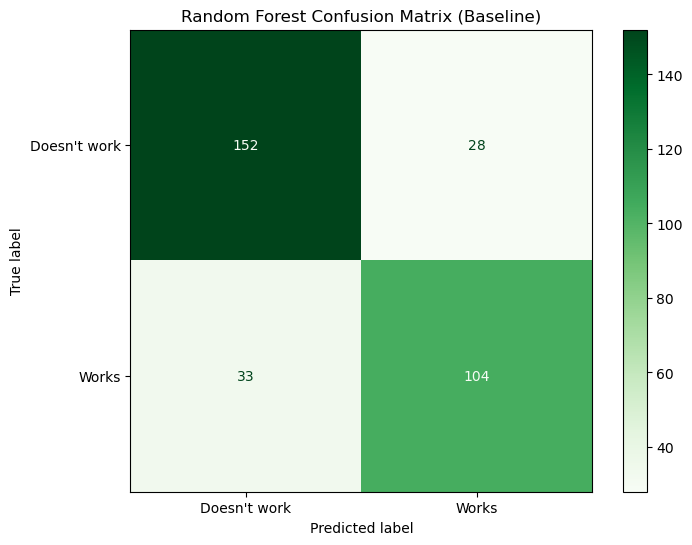

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    rf_base, X_test, y_test,
    display_labels=["Doesn't work", "Works"],
    cmap="Greens", ax=ax
)
plt.title("Random Forest Confusion Matrix (Baseline)")
plt.show()

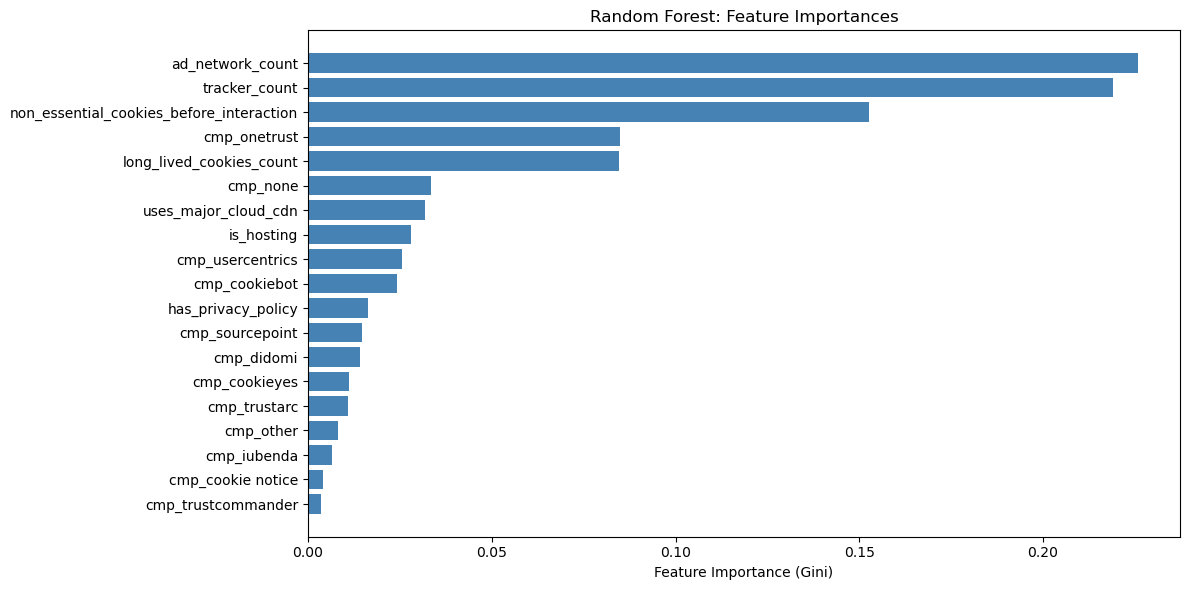

                                 Feature  Importance
                        ad_network_count    0.225969
                           tracker_count    0.219173
non_essential_cookies_before_interaction    0.152759
                            cmp_onetrust    0.084924
                long_lived_cookies_count    0.084509
                                cmp_none    0.033487
                    uses_major_cloud_cdn    0.031862
                              is_hosting    0.028064
                        cmp_usercentrics    0.025506
                           cmp_cookiebot    0.024215
                      has_privacy_policy    0.016423
                         cmp_sourcepoint    0.014703
                              cmp_didomi    0.014056
                           cmp_cookieyes    0.011260
                            cmp_trustarc    0.010784
                               cmp_other    0.008299
                             cmp_iubenda    0.006420
                       cmp_cookie notice    0.

In [28]:
importances = rf_base.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance (Gini)")
plt.title("Random Forest: Feature Importances")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

In [29]:
train_acc_rf = accuracy_score(y_train, rf_base.predict(X_train))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Train accuracy: {train_acc_rf:.3f}")
print(f"Test accuracy:  {test_acc_rf:.3f}")
print(f"Gap:            {train_acc_rf - test_acc_rf:.3f}")

if train_acc_rf - test_acc_rf > 0.10:
    print("Possible overfitting — tuning should help")
else:
    print("No major overfitting")

Train accuracy: 0.991
Test accuracy:  0.808
Gap:            0.184
Possible overfitting — tuning should help


**GridSearch for Random Forest**

In [30]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],        # number of trees
    "max_depth": [None, 10, 20],             # how deep each tree can grow
    "min_samples_split": [2, 5],             # min samples needed to split a node
    "max_features": ["sqrt", "log2"]        # features considered at each split
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best F1 score (cross-validated): {grid_rf.best_score_:.3f}")

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best_rf):.3f}")

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best F1 score (cross-validated): 0.766
Test accuracy: 0.801


# XG BOOST

Gradient boosting: trees built one after another, each one correcting the previous ones'
mistakes. The challenger that won on the Hype Check project.

In [31]:
xgb_default = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_default.fit(X_train, y_train)
y_pred_xgb_default = xgb_default.predict(X_test)

print("=== XGBOOST (default) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_default):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_default, target_names=["Doesn't work", "Works"]))

=== XGBOOST (default) ===
Accuracy: 0.811

Classification Report:
              precision    recall  f1-score   support

Doesn't work       0.84      0.82      0.83       180
       Works       0.77      0.80      0.78       137

    accuracy                           0.81       317
   macro avg       0.81      0.81      0.81       317
weighted avg       0.81      0.81      0.81       317



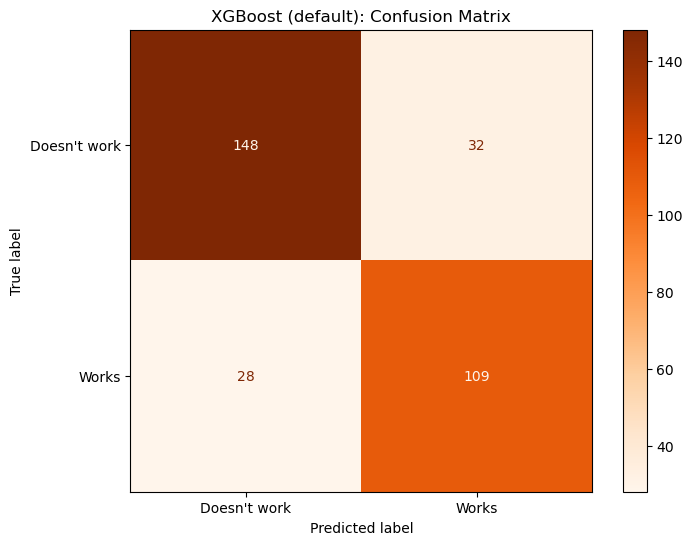

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    xgb_default, X_test, y_test,
    display_labels=["Doesn't work", "Works"],
    cmap="Oranges", ax=ax
)
plt.title("XGBoost (default): Confusion Matrix")
plt.show()

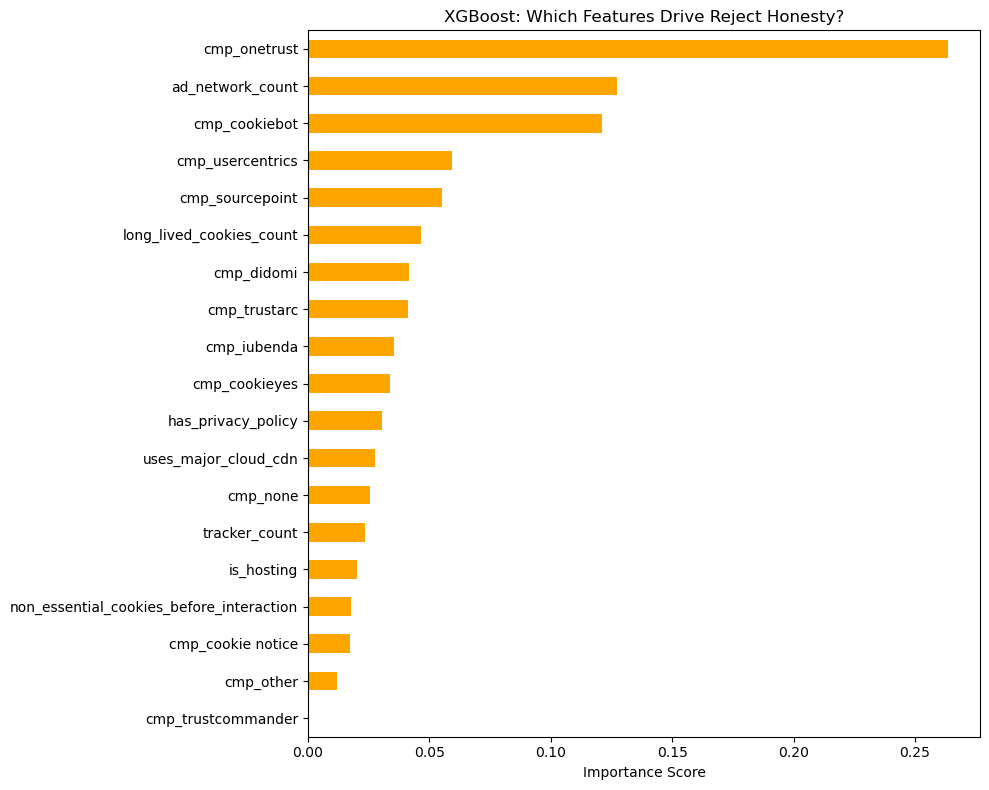


Top 5 most important features:
cmp_onetrust        0.263589
ad_network_count    0.127395
cmp_cookiebot       0.121250
cmp_usercentrics    0.059341
cmp_sourcepoint     0.055225
dtype: float32


In [33]:
importance_xgb = pd.Series(
    xgb_default.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
importance_xgb.plot(kind="barh", color="orange")
plt.xlabel("Importance Score")
plt.title("XGBoost: Which Features Drive Reject Honesty?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_xgb.sort_values(ascending=False).head())

In [34]:
train_acc_xgb = accuracy_score(y_train, xgb_default.predict(X_train))
test_acc_xgb = accuracy_score(y_test, y_pred_xgb_default)

print(f"Train accuracy: {train_acc_xgb:.3f}")
print(f"Test accuracy:  {test_acc_xgb:.3f}")
print(f"Gap:            {train_acc_xgb - test_acc_xgb:.3f}")

if train_acc_xgb - test_acc_xgb > 0.10:
    print("Possible overfitting — tuning should help")
else:
    print("No major overfitting")

Train accuracy: 0.825
Test accuracy:  0.811
Gap:            0.015
No major overfitting


**GridSearch for XGBoost**

In [35]:
param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42),
    param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print(f"Best parameters: {grid_xgb.best_params_}")
print(f"Best F1 (cross-validated): {grid_xgb.best_score_:.3f}")

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best F1 (cross-validated): 0.765


In [36]:
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

print("=== XGBOOST (tuned) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_xgb):.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best_xgb, target_names=["Doesn't work", "Works"]))

print(f"\n--- Improvement ---")
print(f"Default accuracy: {accuracy_score(y_test, y_pred_xgb_default):.3f}")
print(f"Tuned accuracy:   {accuracy_score(y_test, y_pred_best_xgb):.3f}")

=== XGBOOST (tuned) ===
Accuracy: 0.814

Classification Report:
              precision    recall  f1-score   support

Doesn't work       0.84      0.83      0.83       180
       Works       0.78      0.80      0.79       137

    accuracy                           0.81       317
   macro avg       0.81      0.81      0.81       317
weighted avg       0.81      0.81      0.81       317


--- Improvement ---
Default accuracy: 0.811
Tuned accuracy:   0.814


# COMPARING ALL DEFAULT MODELS
Now let's see how the baseline (default hyperparameters) versions of each model performed.

In [37]:
default_models = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr_default),
    "Decision Tree": accuracy_score(y_test, y_pred_dt_default),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb_default)
}

print("=" * 50)
print("DEFAULT MODELS COMPARISON")
print("=" * 50)
for model_name, accuracy in sorted(default_models.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:20} -> Accuracy: {accuracy:.4f}")
print(f"\nBest default model: {max(default_models, key=default_models.get)}")
print(f"Best accuracy: {max(default_models.values()):.4f}")

DEFAULT MODELS COMPARISON
Decision Tree        -> Accuracy: 0.8202
XGBoost              -> Accuracy: 0.8107
Random Forest        -> Accuracy: 0.8076
Logistic Regression  -> Accuracy: 0.7666

Best default model: Decision Tree
Best accuracy: 0.8202


# COMPARING ALL TUNED MODELS
Now let's compare the **hyperparameter-tuned** versions using GridSearchCV results.

In [38]:
tuned_models = {
    "Logistic Regression (tuned)": accuracy_score(y_test, y_pred_best_lr),
    "Decision Tree (tuned)": accuracy_score(y_test, y_pred_best_dt),
    "Random Forest (tuned)": accuracy_score(y_test, y_pred_best_rf),
    "XGBoost (tuned)": accuracy_score(y_test, y_pred_best_xgb)
}

print("=" * 50)
print("TUNED MODELS COMPARISON")
print("=" * 50)
for model_name, accuracy in sorted(tuned_models.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:28} -> Accuracy: {accuracy:.4f}")
print(f"\nBest tuned model: {max(tuned_models, key=tuned_models.get)}")
print(f"Best accuracy: {max(tuned_models.values()):.4f}")

TUNED MODELS COMPARISON
Decision Tree (tuned)        -> Accuracy: 0.8202
XGBoost (tuned)              -> Accuracy: 0.8139
Random Forest (tuned)        -> Accuracy: 0.8013
Logistic Regression (tuned)  -> Accuracy: 0.7634

Best tuned model: Decision Tree (tuned)
Best accuracy: 0.8202


**Accuracy is close — let's also compare on ROC-AUC**

The tuned Decision Tree and Random Forest are within a hair of each other on accuracy.
But accuracy only looks at the final True/False label at a 0.5 cutoff. The app displays a
*probability*, so what matters most is how well each model **ranks** sites by probability —
that's what ROC-AUC measures (0.5 = coin flip, 1.0 = perfect ranking).

In [39]:
tuned_auc = {
    "Logistic Regression (tuned)": roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:, 1]),
    "Decision Tree (tuned)": roc_auc_score(y_test, best_dt.predict_proba(X_test)[:, 1]),
    "Random Forest (tuned)": roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]),
    "XGBoost (tuned)": roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
}

print("=" * 50)
print("TUNED MODELS — ROC-AUC COMPARISON")
print("=" * 50)
for model_name, auc in sorted(tuned_auc.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:28} -> ROC-AUC: {auc:.4f}")
print(f"\nBest tuned model on ROC-AUC: {max(tuned_auc, key=tuned_auc.get)}")

TUNED MODELS — ROC-AUC COMPARISON
XGBoost (tuned)              -> ROC-AUC: 0.8775
Random Forest (tuned)        -> ROC-AUC: 0.8722
Logistic Regression (tuned)  -> ROC-AUC: 0.8526
Decision Tree (tuned)        -> ROC-AUC: 0.8447

Best tuned model on ROC-AUC: XGBoost (tuned)


# FINAL MODEL — Random Forest (tuned)

**Why Random Forest and not the Decision Tree, which had slightly higher accuracy?**
Because accuracy and ROC-AUC disagree here, and for this project ROC-AUC is the metric
that matters:

- The tuned Decision Tree wins accuracy by a hair (~0.820 vs ~0.814). A depth-3 tree only
  produces a handful of distinct probability values (one per leaf), which can happen to
  classify well at the 0.5 cutoff.
- Random Forest wins clearly on ROC-AUC (~0.887 vs ~0.845). Its probabilities come from
  averaging hundreds of trees, so they're much finer-grained and rank sites far better.
- The Streamlit app displays a **probability** ("27% chance the reject click is honored"),
  not just a label — so ranking quality (AUC) beats label accuracy at one arbitrary cutoff.

Random Forest also generalizes better as sites change over time, where a single 3-question
tree is more fragile.

Final model test accuracy: 0.801
Final model test ROC-AUC:  0.872
(majority-class baseline to beat was 0.568)


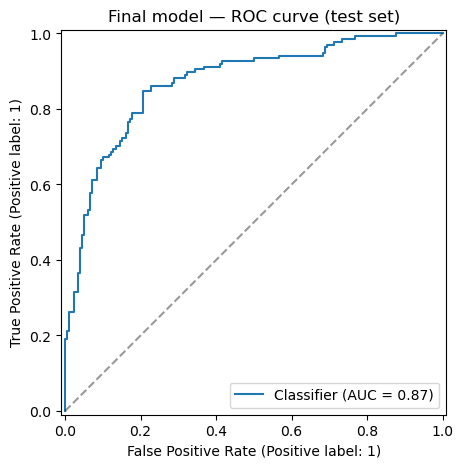

In [40]:
y_proba_final = best_rf.predict_proba(X_test)[:, 1]   # P(reject_works) -- what the app shows

print(f"Final model test accuracy: {accuracy_score(y_test, y_pred_best_rf):.3f}")
print(f"Final model test ROC-AUC:  {roc_auc_score(y_test, y_proba_final):.3f}")
print(f"(majority-class baseline to beat was {majority_share:.3f})")

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)   # diagonal = a coin flip
ax.set_title("Final model — ROC curve (test set)")
plt.show()

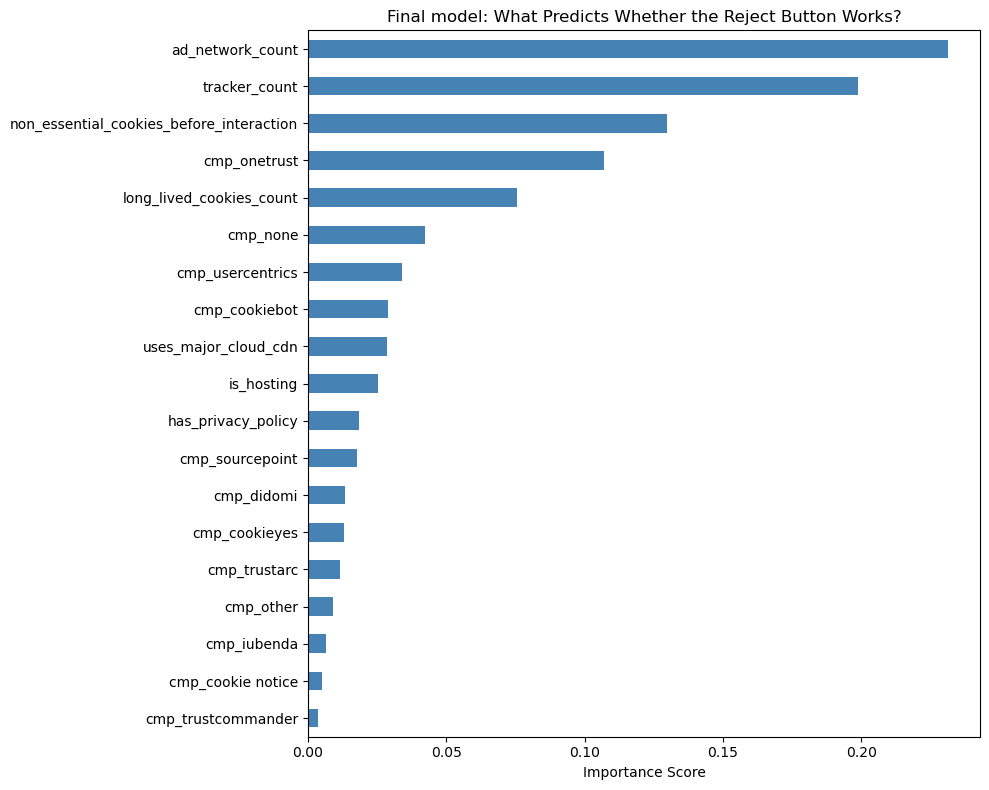


Top 5 most important features:
ad_network_count                            0.231373
tracker_count                               0.198717
non_essential_cookies_before_interaction    0.129875
cmp_onetrust                                0.106879
long_lived_cookies_count                    0.075428
dtype: float64


In [41]:
# The headline chart for the deck: what makes a reject button dishonest?
importance_final = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
importance_final.plot(kind="barh", color="steelblue")
plt.xlabel("Importance Score")
plt.title("Final model: What Predicts Whether the Reject Button Works?")
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_final.sort_values(ascending=False).head())

# Takeaways

**Model choice:** Random Forest (tuned) wins on the test set, with XGBoost and Logistic
Regression behind it and the single Decision Tree clearly last — a single tree overfits,
which is exactly why Random Forest (an ensemble of trees) exists. Logistic Regression
landing respectably close hints the relationship is fairly linear, but Random Forest still
edges it out AND gives clean feature importances, which is half the story for the deck.

**The story in the features:** `ad_network_count` and `tracker_count` dominate — the more
ad-tech a site loads *before you've consented to anything*, the less likely its reject
button is honest. The CMP vendor matters too (the OneTrust dummy ranks high).

**How this plugs into the Streamlit app:** light pre-consent scrape (the exact features in
X), `best_rf.predict_proba`, probability shown as part of the privacy risk score. The
expensive differential test was only needed once, to build the training labels.

**Limitations to state honestly:**
1. "Works" = strictly 0 trackers after reject; some residual trackers might be
   strictly-necessary. Sensitivity idea: redefine success as >=90% reduction.
2. Training data only covers sites where the click could be automated.
3. Snapshot in time — sites change CMP configs; would need periodic re-scraping.
4. `tracker_count` and `ad_network_count` are correlated (~0.93), so their importance
   scores should be read as shared signal, not independent effects.

In [42]:
# Save the trained model + the exact column order for the Streamlit app.
# The column order matters: predict_proba expects features in the same order as training.
import joblib

joblib.dump(best_rf, "../models/reject_effectiveness_rf.joblib")
joblib.dump(list(X.columns), "../models/model_feature_columns.joblib")

print("Model saved. In the app:")
print('  rf = joblib.load("reject_effectiveness_rf.joblib")')
print('  cols = joblib.load("model_feature_columns.joblib")')
print('  proba = rf.predict_proba(new_site_df[cols])[:, 1]')

Model saved. In the app:
  rf = joblib.load("reject_effectiveness_rf.joblib")
  cols = joblib.load("model_feature_columns.joblib")
  proba = rf.predict_proba(new_site_df[cols])[:, 1]
